In [42]:
import numpy as np
import pandas as pd

import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch
DEVICE = 'GPU' if torch.cuda.is_available() else 'CPU'
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, brier_score_loss
from sklearn.calibration import CalibrationDisplay

print(f"Using device: {DEVICE}")

Using device: GPU


In [43]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")
df_external = pd.read_csv("external/f1_strategy_dataset_v4.csv")
print("Train Rows: ", df_train.shape[0], " columns: ", df_train.shape[1])
print("Test Rows: ", df_test.shape[0], " columns: ", df_test.shape[1])
print("External Rows: ", df_external.shape[0], " columns: ", df_external.shape[1])
df_train.head()

Train Rows:  439140  columns:  16
Test Rows:  188165  columns:  15
External Rows:  2669  columns:  15


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [44]:
df_train = df_train.drop("id", axis=1)

In [45]:
TARGET = "PitNextLap"
BASE = df_train.columns.drop(TARGET).to_list()

In [46]:

numerical_features = ['LapNumber', 'TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress']
categorical_features = ['Year', 'PitStop', 'Stint', 'Position']
obj_categorical_features = ['Compound', 'Race', 'Driver']

In [47]:
class FeatureEngineering():

    def __init__(
        self,
        target,
        numerical_features,
        categorical_features,
        obj_categorical_features,
        BASE
    ):
        self.target = target
        self.numerical_features = numerical_features
        self.categorical_features = categorical_features
        self.obj_categorical_features = obj_categorical_features
        self.BASE = BASE

    # ============================================================
    # TARGET SIGNAL FROM ORIGINAL DATA
    # ============================================================

    def signal_from_original(self, df, df_original):

        df = df.copy()

        # Apply to both categorical groups
        all_categorical_features = (
            self.categorical_features +
            self.obj_categorical_features
        )

        for col in all_categorical_features:

            if col not in df_original.columns:
                continue

            means = df_original.groupby(col)[self.target].mean()
            medians = df_original.groupby(col)[self.target].median()
            counts = df_original.groupby(col)[self.target].count()

            df[f'{col}_mean'] = (
                df[col]
                .map(means)
                .fillna(df_original[self.target].mean())
            )

            df[f'{col}_median'] = (
                df[col]
                .map(medians)
                .fillna(df_original[self.target].median())
            )

            df[f'{col}_count'] = (
                df[col]
                .map(counts)
                .fillna(0)
            )

        return df

    # ============================================================
    # BINNING NUMERICAL FEATURES
    # ============================================================

    def binning_features(self, df):

        df = df.copy()

        for col in self.numerical_features:

            # Quantile bins
            df[f'{col}_qcut_5'] = (
                pd.qcut(
                    df[col],
                    q=5,
                    labels=False,
                    duplicates='drop'
                )
                .fillna(-1)
                .astype(int)
            )

            # Equal-width bins
            df[f'{col}_cut_5'] = (
                pd.cut(
                    df[col],
                    bins=5,
                    labels=False,
                    duplicates='drop'
                )
                .fillna(-1)
                .astype(int)
            )

            # Rounded groups
            df[f'{col}_round'] = (
                (df[col] / 20)
                .round()
                .fillna(-1)
                .astype(int)
            )

        return df

    # ============================================================
    # FREQUENCY ENCODING
    # ============================================================

    def frequency_encoding(self, df):

        df = df.copy()

        freq_enc = {
            col: df[col].value_counts().to_dict()
            for col in self.BASE
            if col in df.columns
        }

        for col in self.BASE:

            if col not in df.columns:
                continue

            df[f'{col}_freq'] = (
                df[col]
                .map(freq_enc[col])
                .fillna(1)
            )

        return df

    # ============================================================
    # DIGIT POSITION FEATURES
    # ONLY FOR NUMERICAL FEATURES
    # ============================================================

    def extract_digit_positions(self, df):

        df = df.copy()

        for col in self.numerical_features:

            if col not in df.columns:
                continue

            col_numeric = (
                pd.to_numeric(
                    df[col],
                    errors='coerce'
                )
                .fillna(0)
                .astype(int)
            )

            col_str = (
                col_numeric
                .abs()
                .astype(str)
                .str.zfill(5)
            )

            df[f'{col}_digit_units'] = (
                col_str.str[-1].astype(int)
            )

            df[f'{col}_digit_tens'] = (
                col_str.str[-2].astype(int)
            )

            df[f'{col}_digit_hundreds'] = (
                col_str.str[-3].astype(int)
            )

        return df

    # ============================================================
    # NUMERICAL → CATEGORICAL
    # ============================================================

    def encode_numerical_as_categorical(self, df):

        df = df.copy()

        for col in self.numerical_features:

            if col not in df.columns:
                continue

            df[f'{col}_cat'] = (
                df[col]
                .fillna(-1)
                .astype(str)
            )

        return df

    # ============================================================
    # INTEGER CATEGORICAL → STRING CATEGORICAL
    # ============================================================

    def encode_categorical_features(self, df):

        df = df.copy()

        for col in self.categorical_features:

            if col not in df.columns:
                continue

            df[f'{col}_cat'] = (
                df[col]
                .fillna(-1)
                .astype(str)
            )

        return df

    # ============================================================
    # OBJECT CATEGORICAL FEATURES
    # ============================================================

    def encode_object_categorical_features(self, df):

        df = df.copy()

        for col in self.obj_categorical_features:

            if col not in df.columns:
                continue

            df[col] = (
                df[col]
                .fillna('UNKNOWN')
                .astype(str)
            )

        return df

    # ============================================================
    # COMPLETE TRANSFORMATION
    # ============================================================

    def transform_all(self, df, df_original):

        df = df.copy()

        # Target signal
        df = self.signal_from_original(
            df,
            df_original
        )

        # Optional binning
        # df = self.binning_features(df)

        # Optional frequency encoding
        # df = self.frequency_encoding(df)

        # Numerical digit features
        df = self.extract_digit_positions(df)

        # Numerical → categorical
        df = self.encode_numerical_as_categorical(df)

        # Integer categorical → categorical
        df = self.encode_categorical_features(df)

        # Object categorical
        df = self.encode_object_categorical_features(df)

        return df

In [48]:
feature_engineering = FeatureEngineering(
    target='PitNextLap',
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    obj_categorical_features=obj_categorical_features,
    BASE=BASE
)

In [49]:
print(categorical_features)
print(numerical_features)
print(obj_categorical_features)

['Year', 'PitStop', 'Stint', 'Position']
['LapNumber', 'TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress']
['Compound', 'Race', 'Driver']


In [50]:
df_train_final = feature_engineering.transform_all(df=df_train, df_original=df_external)
df_test_final = feature_engineering.transform_all(df=df_test, df_original=df_external)

categorical_features.extend([c for c in df_train_final.columns if '_cat' in c])
all_categorical_features = categorical_features + obj_categorical_features


In [51]:
print(categorical_features)
print(all_categorical_features)

['Year', 'PitStop', 'Stint', 'Position', 'LapNumber_cat', 'TyreLife_cat', 'LapTime (s)_cat', 'LapTime_Delta_cat', 'Cumulative_Degradation_cat', 'RaceProgress_cat', 'Year_cat', 'PitStop_cat', 'Stint_cat', 'Position_cat']
['Year', 'PitStop', 'Stint', 'Position', 'LapNumber_cat', 'TyreLife_cat', 'LapTime (s)_cat', 'LapTime_Delta_cat', 'Cumulative_Degradation_cat', 'RaceProgress_cat', 'Year_cat', 'PitStop_cat', 'Stint_cat', 'Position_cat', 'Compound', 'Race', 'Driver']


In [52]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

yeo_cols = ['LapTime (s)', 'TyreLife']
yeo = PowerTransformer(method='yeo-johnson', standardize=True)
df_train_final[yeo_cols] = yeo.fit_transform(df_train_final[yeo_cols])
df_test_final[yeo_cols] = yeo.transform(df_test_final[yeo_cols])

qt_cols = ['LapTime_Delta', 'Cumulative_Degradation']
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_train_final[qt_cols] = qt.fit_transform(df_train_final[qt_cols])
df_test_final[qt_cols] = qt.transform(df_test_final[qt_cols])

print("Skewness after transformation:")
print(df_train_final[['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'TyreLife']].skew())

Skewness after transformation:
LapTime (s)              -0.010944
LapTime_Delta            -0.009788
Cumulative_Degradation    0.023785
TyreLife                 -0.049772
dtype: float64


In [53]:
X = df_train_final.drop([TARGET], axis=1).copy()
y = df_train[TARGET].copy()
X_test = df_test_final.drop(['id'], axis=1).copy()

In [54]:
%%time

cat_params = {
    'iterations': 2500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 8.5,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 200,
    'early_stopping_rounds': 200,
    'auto_class_weights':'Balanced',
    'task_type': 'GPU',
    'cat_features': all_categorical_features
}

n_folds = 5

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_preds = np.zeros(len(df_train))
y_test_preds = np.zeros(len(df_test))
fold_scores = [] 

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n===== Fold {fold + 1} =====")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(**cat_params)
    
    model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

    val_probs = model.predict_proba(X_val)[:, 1]
    fold_test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    y_test_preds += fold_test_probs / n_folds

    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

total_oof_score = roc_auc_score(y, oof_preds) 
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")


===== Fold 1 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9163585	best: 0.9163585 (0)	total: 51.5ms	remaining: 2m 8s
200:	test: 0.9467621	best: 0.9467621 (200)	total: 9.81s	remaining: 1m 52s
400:	test: 0.9491284	best: 0.9491284 (400)	total: 19.5s	remaining: 1m 42s
600:	test: 0.9500895	best: 0.9500895 (600)	total: 29.3s	remaining: 1m 32s
800:	test: 0.9506071	best: 0.9506071 (800)	total: 39.1s	remaining: 1m 22s
1000:	test: 0.9509168	best: 0.9509168 (1000)	total: 48.8s	remaining: 1m 13s
1200:	test: 0.9511539	best: 0.9511559 (1197)	total: 58.5s	remaining: 1m 3s
1400:	test: 0.9513454	best: 0.9513454 (1400)	total: 1m 8s	remaining: 53.4s
1600:	test: 0.9514717	best: 0.9514717 (1600)	total: 1m 17s	remaining: 43.7s
1800:	test: 0.9515901	best: 0.9515913 (1790)	total: 1m 27s	remaining: 34s
2000:	test: 0.9516534	best: 0.9516534 (2000)	total: 1m 37s	remaining: 24.3s
2200:	test: 0.9517136	best: 0.9517208 (2186)	total: 1m 47s	remaining: 14.5s
2400:	test: 0.9517491	best: 0.9517491 (2400)	total: 1m 56s	remaining: 4.82s
2499:	test: 0.9517369	best: 0.

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9113228	best: 0.9113228 (0)	total: 45.8ms	remaining: 1m 54s
200:	test: 0.9442786	best: 0.9442786 (200)	total: 9.47s	remaining: 1m 48s
400:	test: 0.9466183	best: 0.9466183 (400)	total: 19.1s	remaining: 1m 39s
600:	test: 0.9475873	best: 0.9475873 (600)	total: 28.9s	remaining: 1m 31s
800:	test: 0.9481554	best: 0.9481554 (800)	total: 38.6s	remaining: 1m 21s
1000:	test: 0.9484848	best: 0.9484848 (1000)	total: 48.3s	remaining: 1m 12s
1200:	test: 0.9486936	best: 0.9486936 (1200)	total: 58s	remaining: 1m 2s
1400:	test: 0.9488797	best: 0.9488797 (1400)	total: 1m 7s	remaining: 53.1s
1600:	test: 0.9489588	best: 0.9489599 (1598)	total: 1m 17s	remaining: 43.6s
1800:	test: 0.9490265	best: 0.9490469 (1760)	total: 1m 27s	remaining: 34s
2000:	test: 0.9491184	best: 0.9491223 (1997)	total: 1m 37s	remaining: 24.4s
2200:	test: 0.9491386	best: 0.9491450 (2195)	total: 1m 47s	remaining: 14.6s
2400:	test: 0.9491768	best: 0.9491840 (2356)	total: 1m 57s	remaining: 4.84s
2499:	test: 0.9491640	best: 0.9

...

0:	test: 0.9135355	best: 0.9135355 (0)	total: 45.7ms	remaining: 1m 54s
200:	test: 0.9459136	best: 0.9459136 (200)	total: 9.55s	remaining: 1m 49s
400:	test: 0.9480202	best: 0.9480202 (400)	total: 19.2s	remaining: 1m 40s
600:	test: 0.9489669	best: 0.9489669 (600)	total: 28.9s	remaining: 1m 31s
800:	test: 0.9495565	best: 0.9495565 (800)	total: 38.6s	remaining: 1m 21s
1000:	test: 0.9498957	best: 0.9498957 (1000)	total: 48.5s	remaining: 1m 12s
1200:	test: 0.9501520	best: 0.9501531 (1199)	total: 58.4s	remaining: 1m 3s
1400:	test: 0.9502711	best: 0.9502711 (1400)	total: 1m 8s	remaining: 53.7s
1600:	test: 0.9503773	best: 0.9503850 (1592)	total: 1m 18s	remaining: 44.1s
1800:	test: 0.9504573	best: 0.9504620 (1796)	total: 1m 28s	remaining: 34.3s
2000:	test: 0.9504842	best: 0.9505089 (1962)	total: 1m 38s	remaining: 24.6s
bestTest = 0.9505088925
bestIteration = 1962
Shrink model to first 1963 iterations.
Fold 3 ROC-AUC Score: 0.95051

===== Fold 4 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9129071	best: 0.9129071 (0)	total: 44.9ms	remaining: 1m 52s
200:	test: 0.9451094	best: 0.9451094 (200)	total: 9.37s	remaining: 1m 47s
400:	test: 0.9474230	best: 0.9474230 (400)	total: 18.9s	remaining: 1m 39s
600:	test: 0.9483919	best: 0.9483919 (600)	total: 28.6s	remaining: 1m 30s
800:	test: 0.9489486	best: 0.9489486 (800)	total: 38.1s	remaining: 1m 20s
1000:	test: 0.9493592	best: 0.9493604 (997)	total: 48.8s	remaining: 1m 13s
1200:	test: 0.9496552	best: 0.9496565 (1198)	total: 58.8s	remaining: 1m 3s
1400:	test: 0.9498609	best: 0.9498625 (1398)	total: 1m 8s	remaining: 54s
1600:	test: 0.9500360	best: 0.9500387 (1596)	total: 1m 18s	remaining: 44.3s
1800:	test: 0.9501182	best: 0.9501209 (1793)	total: 1m 28s	remaining: 34.5s
2000:	test: 0.9501740	best: 0.9501784 (1978)	total: 1m 38s	remaining: 24.7s
2200:	test: 0.9501838	best: 0.9502044 (2126)	total: 1m 48s	remaining: 14.7s
bestTest = 0.9502043724
bestIteration = 2126
Shrink model to first 2127 iterations.
Fold 4 ROC-AUC Score: 

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9145615	best: 0.9145615 (0)	total: 45.2ms	remaining: 1m 53s
200:	test: 0.9459052	best: 0.9459052 (200)	total: 9.35s	remaining: 1m 46s
400:	test: 0.9481880	best: 0.9481880 (400)	total: 19s	remaining: 1m 39s
600:	test: 0.9491913	best: 0.9491913 (600)	total: 28.9s	remaining: 1m 31s
800:	test: 0.9497377	best: 0.9497377 (800)	total: 38.5s	remaining: 1m 21s
1000:	test: 0.9500231	best: 0.9500231 (1000)	total: 48.3s	remaining: 1m 12s
1200:	test: 0.9502462	best: 0.9502499 (1193)	total: 58s	remaining: 1m 2s
1400:	test: 0.9504282	best: 0.9504282 (1400)	total: 1m 7s	remaining: 53.2s
1600:	test: 0.9505093	best: 0.9505129 (1595)	total: 1m 17s	remaining: 43.7s
1800:	test: 0.9505840	best: 0.9505841 (1799)	total: 1m 27s	remaining: 34s
2000:	test: 0.9506742	best: 0.9506742 (2000)	total: 1m 37s	remaining: 24.3s
2200:	test: 0.9507037	best: 0.9507074 (2195)	total: 1m 47s	remaining: 14.6s
2400:	test: 0.9507460	best: 0.9507558 (2383)	total: 1m 57s	remaining: 4.83s
2499:	test: 0.9507583	best: 0.950

Train AUC score is: 0.9504729927057527


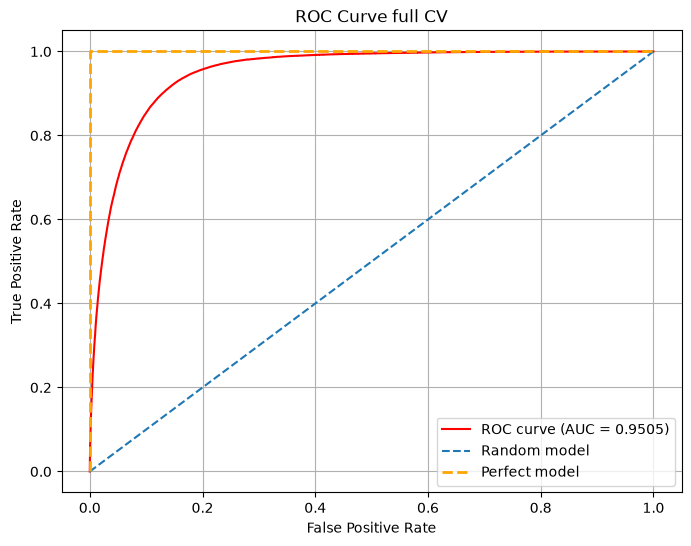

In [55]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)

auc_score = auc(fpr, tpr)
print("Train AUC score is:", auc_score)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})", color='red')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random model')
plt.plot([0, 0, 1], [0, 1, 1], color='orange', linestyle='--', linewidth=2, label='Perfect model')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve full CV")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

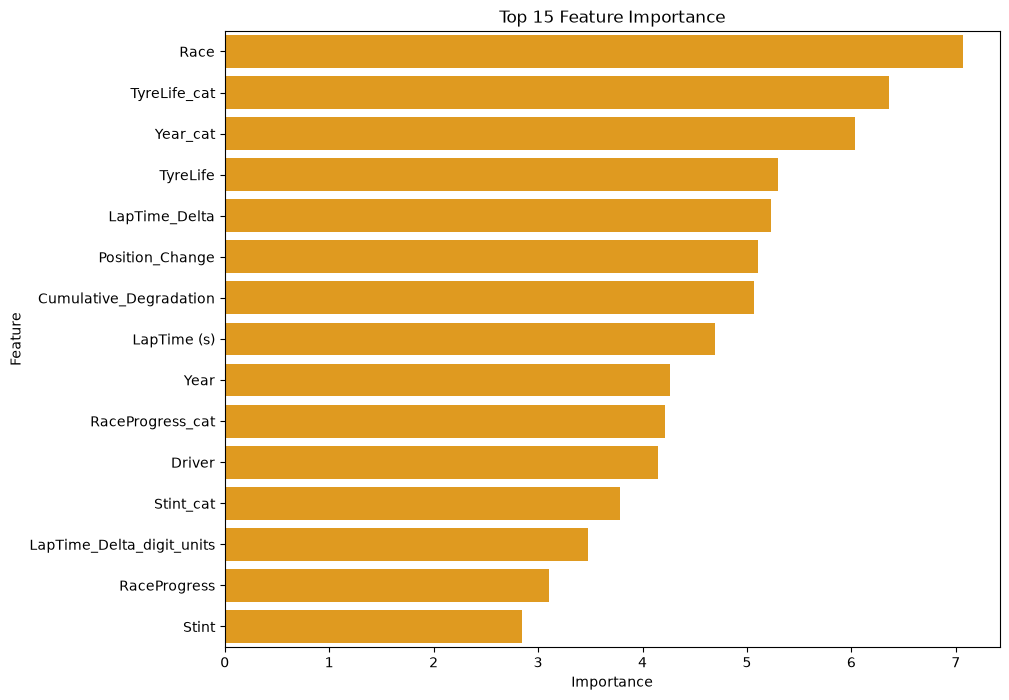

In [56]:
df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.title("Top 15 Feature Importance") 
ax = sns.barplot(x='Importance', y='Feature', data=df_importance, color="#FFA300")